# Task 1 — Brent Oil Time Series EDA and Change Point Model Understanding

**Author:** Mariamawit Ewnetu Alemu  
**Program:** 10 Academy — Artificial Intelligence Mastery  
**Interim objective:** create the analytical foundation needed for Bayesian change point detection.

This notebook provides observable evidence for Task 1b: the Brent data are loaded and validated, raw prices and log returns are visualized, trend/stationarity/volatility properties are investigated, and the purpose and expected outputs of a change point model are explained.

## 1. Planned analysis workflow

1. Load and validate the Brent price data.
2. Load the researched event catalogue.
3. Inspect raw price levels, long-run trend, and major shocks.
4. Calculate log returns and rolling volatility.
5. Test stationarity using both ADF and KPSS.
6. Use the EDA to choose the target variable and likelihood for Bayesian change point modeling.
7. Estimate posterior change dates and before/after parameters in PyMC.
8. Compare change-date posteriors with the event catalogue without treating date matching as proof of causality.
9. Translate results into clear, uncertainty-aware stakeholder statements.

The full workflow and limitations are documented in `docs/analysis_workflow.md` and `docs/assumptions_and_limitations.md`.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.data_loader import load_brent_prices, load_event_data
from src.diagnostics import stationarity_report
from src.features import add_time_series_features, event_window_summary
from src.plotting import (
    plot_log_returns,
    plot_price_with_events,
    plot_raw_price,
    plot_rolling_volatility,
)

PRICE_PATH = PROJECT_ROOT / "data/raw/BrentOilPrices.csv"
EVENT_PATH = PROJECT_ROOT / "data/events/oil_market_events.csv"
FIGURE_DIR = PROJECT_ROOT / "reports/figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

pd.set_option("display.max_colwidth", 90)

## 2. Load and validate the data

The supplied CSV changes date format near the end of the series. The project loader parses both known formats explicitly, validates required columns, checks that prices are positive, removes no records silently, and sorts the data chronologically.

In [2]:
prices = load_brent_prices(PRICE_PATH)
events = load_event_data(EVENT_PATH)
analysis = add_time_series_features(prices, rolling_window=30)

print(f"Rows: {len(analysis):,}")
print(f"Date range: {analysis['Date'].min().date()} to {analysis['Date'].max().date()}")
print(f"Missing values in original fields: {analysis[['Date', 'Price']].isna().sum().sum()}")
print(f"Duplicate dates: {analysis['Date'].duplicated().sum()}")
display(analysis.head())

Rows: 9,011
Date range: 1987-05-20 to 2022-11-14
Missing values in original fields: 0
Duplicate dates: 0


,Date,Price,log_price,log_return,rolling_mean_30,rolling_std_30,annualized_volatility_30
0,1987-05-20,18.63,2.924773,NaN,NaN,NaN,NaN
1,1987-05-21,18.45,2.915064,-0.009709,NaN,NaN,NaN
2,1987-05-22,18.55,2.920470,0.005405,NaN,NaN,NaN
3,1987-05-25,18.60,2.923162,0.002692,NaN,NaN,NaN
4,1987-05-26,18.63,2.924773,0.001612,NaN,NaN,NaN


### Data quality observation

The file contains observations through **14 November 2022**, although the challenge brief describes the dataset as ending on 30 September 2022. This notebook analyzes the file as received and records the discrepancy as a limitation.

In [3]:
summary = analysis['Price'].describe().to_frame('Price summary')
max_row = analysis.loc[analysis['Price'].idxmax(), ['Date', 'Price']]
min_row = analysis.loc[analysis['Price'].idxmin(), ['Date', 'Price']]

display(summary)
print(f"Maximum: ${max_row['Price']:.2f} on {max_row['Date'].date()}")
print(f"Minimum: ${min_row['Price']:.2f} on {min_row['Date'].date()}")

,Price summary
count,9011.000000
mean,48.420782
std,32.860110
min,9.100000
25%,19.050000
50%,38.570000
75%,70.090000
max,143.950000


Maximum: $143.95 on 2008-07-03
Minimum: $9.10 on 1998-12-10


## 3. Raw price series and trend

The raw series is necessary because a level change is economically interpretable in dollars per barrel. It also reveals why a single global mean is unrealistic: the series contains long cycles, sharp shocks, and periods with different price levels.

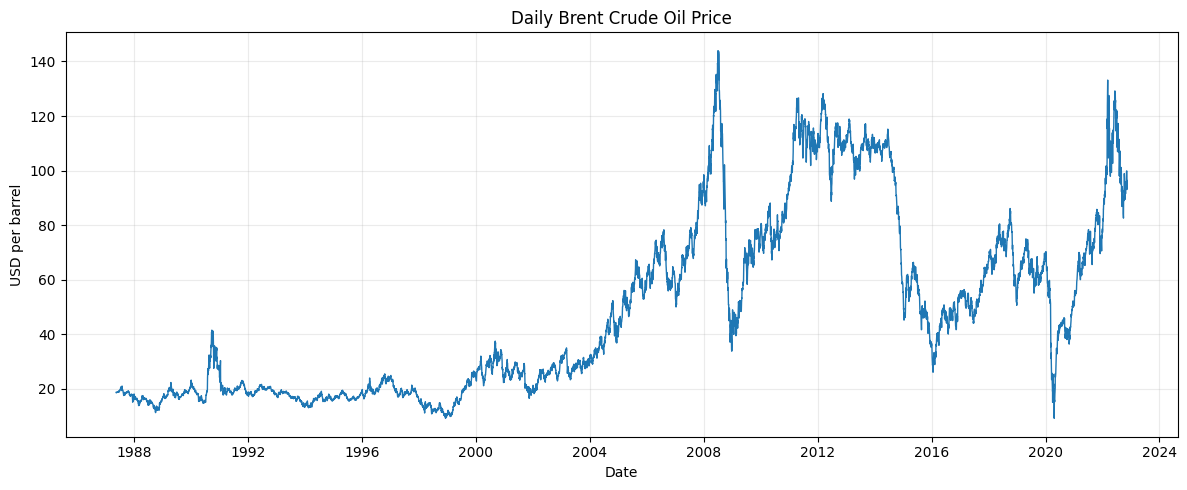

In [4]:
fig = plot_raw_price(analysis, FIGURE_DIR / "raw_brent_price.png")
plt.show()

The plot shows persistent long-run movement rather than fluctuation around one constant mean. The 2008 peak, subsequent financial-crisis decline, 2014-2016 fall, 2020 collapse, and 2021-2022 recovery are visible as distinct market regimes. This pattern suggests that raw prices are likely non-stationary and that a one-change-point model can only be a baseline.

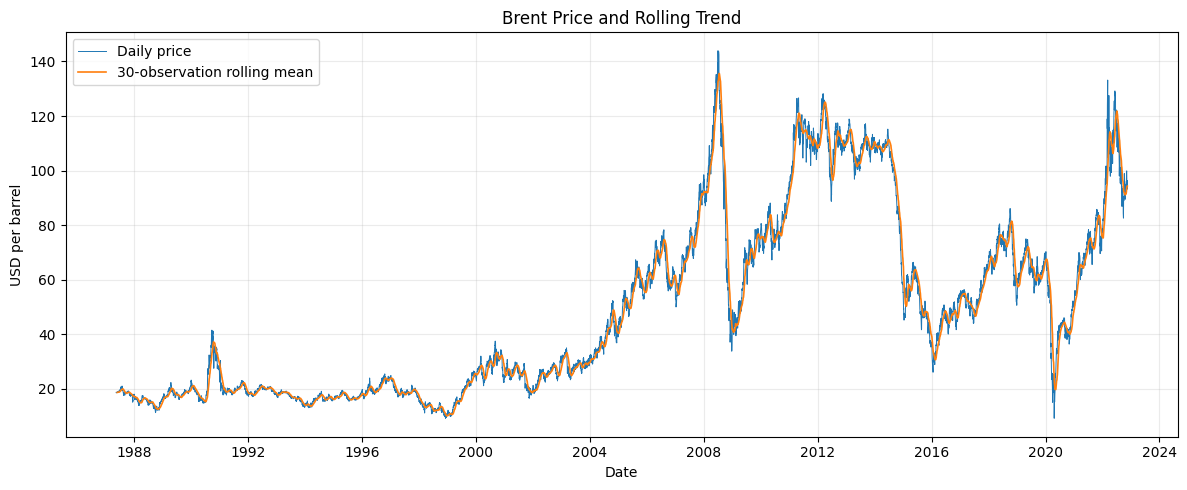

In [5]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(analysis['Date'], analysis['Price'], linewidth=0.7, label='Daily price')
ax.plot(analysis['Date'], analysis['rolling_mean_30'], linewidth=1.2, label='30-observation rolling mean')
ax.set_title('Brent Price and Rolling Trend')
ax.set_xlabel('Date')
ax.set_ylabel('USD per barrel')
ax.legend()
ax.grid(alpha=0.25)
fig.tight_layout()
fig.savefig(FIGURE_DIR / 'price_rolling_mean.png', dpi=160, bbox_inches='tight')
plt.show()

## 4. Log returns

Daily log return is calculated as:

\[
r_t = \log(P_t) - \log(P_{t-1})
\]

Returns measure proportional day-to-day movement and usually remove the long-run drift that makes price levels difficult to model as stationary data.

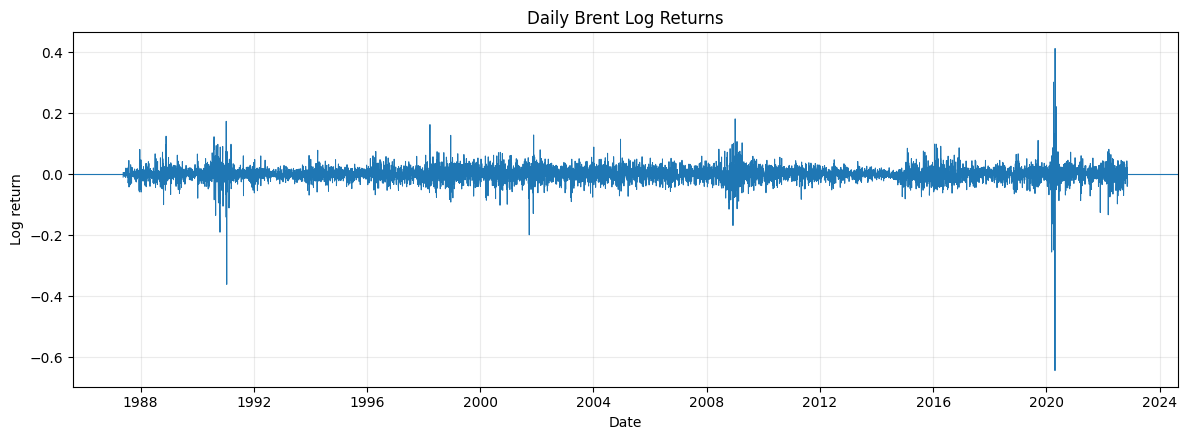

In [6]:
fig = plot_log_returns(analysis, FIGURE_DIR / "brent_log_returns.png")
plt.show()

Returns fluctuate around zero, but their spread is not constant. Large positive and negative movements cluster together, particularly around global crises. The mean may be approximately stable while the variance changes through time, so volatility needs separate attention.

In [7]:
largest_moves = analysis.loc[
    analysis['log_return'].abs().nlargest(10).index,
    ['Date', 'Price', 'log_return']
].sort_values('log_return')
display(largest_moves)

,Date,Price,log_return
8359,2020-04-21,9.12,-0.643699
936,1991-01-17,21.10,-0.361214
8330,2020-03-09,35.33,-0.255175
8347,2020-04-01,14.97,-0.248341
8353,2020-04-09,20.23,-0.220471
3641,2001-09-24,20.63,-0.198906
875,1990-10-22,27.45,-0.190184
8369,2020-05-05,25.46,0.221574
8348,2020-04-02,20.24,0.301613
8360,2020-04-22,13.77,0.412023


## 5. Stationarity testing

Two complementary tests are used:

- **ADF null:** the series has a unit root and is non-stationary.
- **KPSS null:** the series is level-stationary.

A stationary series should normally reject the ADF null while failing to reject the KPSS null.

In [8]:
stationarity = pd.concat(
    [
        stationarity_report(analysis['Price'], 'Price'),
        stationarity_report(analysis['log_return'], 'Log return'),
    ],
    ignore_index=True,
)
display(stationarity)
stationarity.to_csv(PROJECT_ROOT / 'reports/stationarity_results.csv', index=False)

,series,test,statistic,p_value,lags,observations,null_hypothesis,decision_at_5pct
0,Price,ADF,-1.993856,2.892735e-01,29,8981,Unit root / non-stationary,Fail to reject null
1,Price,KPSS,9.558800,1.000000e-02,57,9011,Level-stationary,Reject null
2,Log return,ADF,-16.427113,2.498580e-29,28,8981,Unit root / non-stationary,Reject null
3,Log return,KPSS,0.034274,1.000000e-01,14,9010,Level-stationary,Fail to reject null


### Interpretation

The raw price series fails to reject the ADF unit-root null and rejects the KPSS stationarity null. Both tests therefore point to **non-stationary price levels**. Log returns strongly reject the ADF unit-root null and do not reject the KPSS stationarity null, supporting **stationary returns**.

This informs modeling in two ways. A model on price levels can quantify an economically meaningful change in average dollars per barrel, but it must acknowledge non-stationarity and multiple regimes. A model on log returns is statistically better behaved for short-run analysis, but a mean-return change is less intuitive and may miss changes that appear mainly in volatility.

## 6. Volatility patterns

Rolling annualized volatility is calculated from the standard deviation of the latest 30 observed log returns and scaled by \(\sqrt{252}\). It is a descriptive diagnostic rather than a forecast.

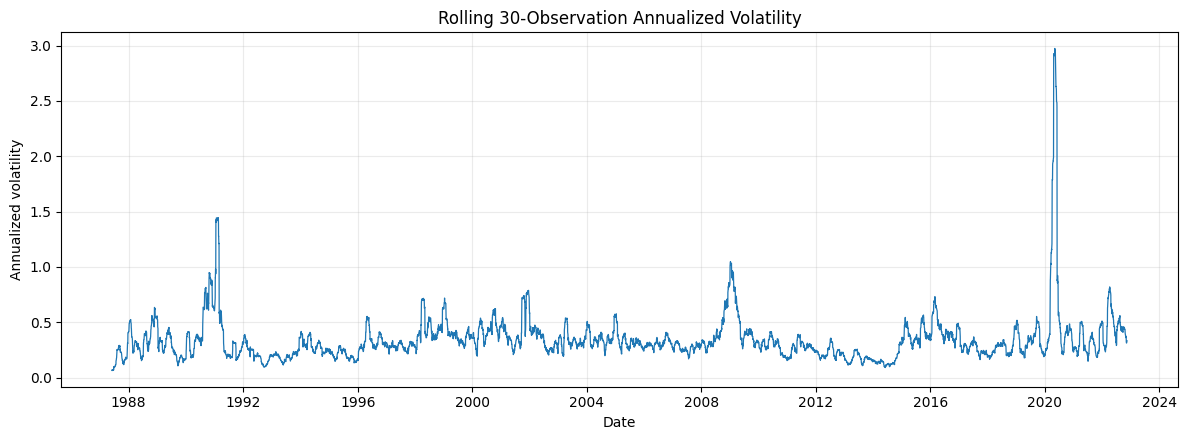

Highest 30-observation annualized volatility: 2.974 on 2020-05-06


In [9]:
fig = plot_rolling_volatility(
    analysis,
    window=30,
    output_path=FIGURE_DIR / 'rolling_volatility.png',
)
plt.show()

vol_col = 'annualized_volatility_30'
max_vol = analysis.loc[analysis[vol_col].idxmax(), ['Date', vol_col]]
print(
    f"Highest 30-observation annualized volatility: {max_vol[vol_col]:.3f} "
    f"on {max_vol['Date'].date()}"
)

The volatility plot confirms strong clustering. The most extreme period is the 2020 demand and storage shock, but elevated volatility is also visible around the Gulf War period and the 2008-2009 financial crisis. This weakens the constant-variance assumption of a simple Normal likelihood. A Student-t likelihood or separate before/after volatility parameters should be considered in the final analysis.

## 7. Researched event dataset

The event dataset contains major conflicts, economic shocks, sanctions, natural disasters, and OPEC/OPEC+ decisions. The hypothesized direction is an analytical expectation only. It is not a target label and is not evidence of realized or causal impact.

In [10]:
print(f"Number of researched events: {len(events)}")
display(
    events[
        ['event_date', 'event_name', 'category', 'hypothesized_short_term_pressure', 'source_name']
    ]
)

Number of researched events: 19


,event_date,event_name,category,hypothesized_short_term_pressure,source_name
0,1990-08-02,Iraq invades Kuwait,Geopolitical conflict,Upward,United Nations Peacekeeping - UNIKOM background
1,1997-07-02,Asian Financial Crisis begins in Thailand,Economic shock,Downward,International Monetary Fund
2,2001-09-11,September 11 attacks,Geopolitical shock,Downward / uncertain,U.S. National Archives
3,2003-03-19,Operation Iraqi Freedom begins,Geopolitical conflict,Upward,U.S. Army Center of Military History
4,2005-08-29,Hurricane Katrina makes Gulf Coast landfall,Supply disruption / natural disaster,Upward,NOAA Office of Response and Restoration
5,2008-09-15,Lehman Brothers files for bankruptcy,Economic shock,Downward,Federal Reserve History
6,2011-02-22,Libyan conflict escalates,Geopolitical conflict,Upward,United Nations Media
7,2012-07-01,EU embargo on Iranian oil fully enters into force,Economic sanctions,Upward,European Council
8,2014-11-27,OPEC maintains 30 million b/d production ceiling,OPEC policy,Downward,"OPEC Bulletin, December 2014"
9,2016-11-30,OPEC Vienna production agreement,OPEC policy,Upward,OPEC


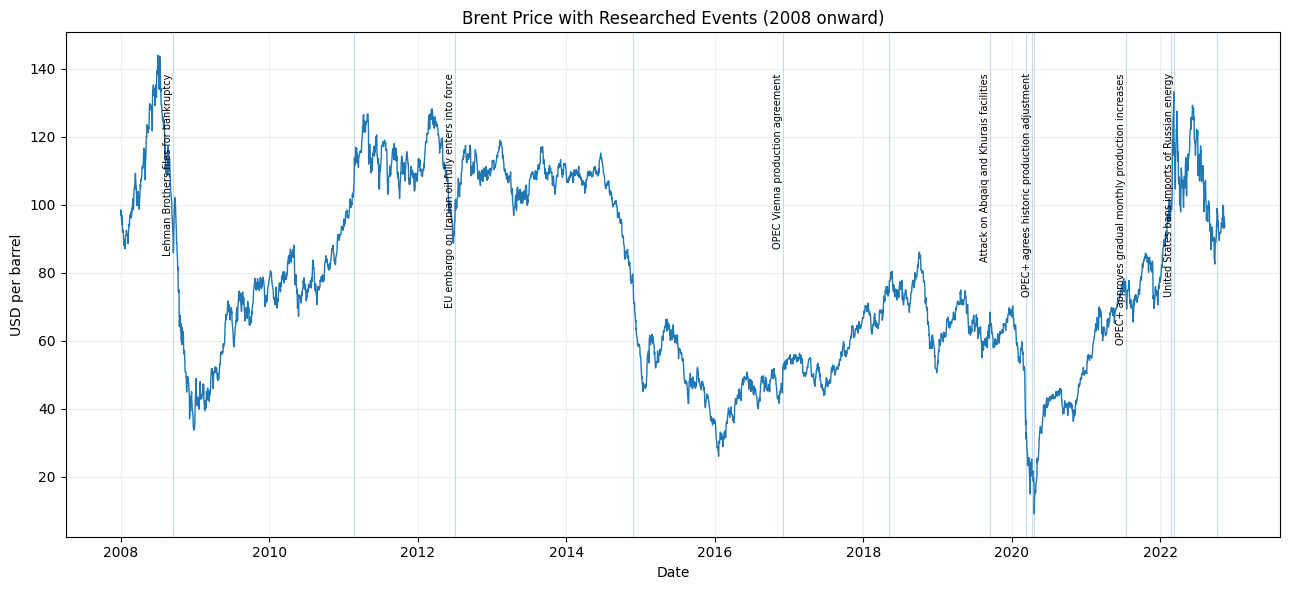

In [11]:
fig = plot_price_with_events(
    analysis,
    events,
    start_date='2008-01-01',
    output_path=FIGURE_DIR / 'price_with_events.png',
)
plt.show()

The event overlay is useful for generating hypotheses, but visual alignment can be misleading. Prices may move before an announcement because it was anticipated, and several events may overlap. A proper change point result must therefore report date uncertainty and competing explanations.

In [12]:
window_results = event_window_summary(
    analysis,
    events,
    observations_before=5,
    observations_after=5,
)
window_results.to_csv(PROJECT_ROOT / 'reports/event_window_summary.csv', index=False)
display(
    window_results[
        ['event_date', 'event_name', 'nearest_trading_date', 'pre_to_post_change_pct']
    ].round({'pre_to_post_change_pct': 2})
)

,event_date,event_name,nearest_trading_date,pre_to_post_change_pct
0,1990-08-02,Iraq invades Kuwait,1990-08-02,38.28
1,1997-07-02,Asian Financial Crisis begins in Thailand,1997-07-02,1.98
2,2001-09-11,September 11 attacks,2001-09-11,4.83
3,2003-03-19,Operation Iraqi Freedom begins,2003-03-19,-23.95
4,2005-08-29,Hurricane Katrina makes Gulf Coast landfall,2005-08-29,-2.60
5,2008-09-15,Lehman Brothers files for bankruptcy,2008-09-15,-0.64
6,2011-02-22,Libyan conflict escalates,2011-02-22,9.91
7,2012-07-01,EU embargo on Iranian oil fully enters into force,2012-07-02,11.79
8,2014-11-27,OPEC maintains 30 million b/d production ceiling,2014-11-28,-12.38
9,2016-11-30,OPEC Vienna production agreement,2016-11-30,11.52


The table above is descriptive: it compares prices five observed trading days before and after each event. It is not an event-study estimate and does not control for other information arriving in the same window.

## 8. Purpose of a Bayesian change point model

A change point model estimates when the data-generating process changed. For a simple mean-shift model:

- \(	au\) is an unknown discrete switch index.
- \(\mu_1\) is the expected value before \(	au\).
- \(\mu_2\) is the expected value after \(	au\).
- `pm.math.switch` assigns \(\mu_1\) or \(\mu_2\) to each observation.
- The likelihood connects the selected mean and an error distribution to the observed data.

MCMC sampling returns posterior distributions, not one guaranteed change date.

### Expected outputs

1. A posterior distribution for \(	au\) and its corresponding calendar date.
2. A credible interval showing date uncertainty.
3. Posterior estimates for before/after means or volatility values.
4. A posterior distribution for the shift size, such as \(\mu_2 - \mu_1\) or percentage change.
5. Trace plots, R-hat, and effective sample size diagnostics.
6. Sensitivity results under alternative variables, windows, or likelihoods.

A narrow posterior peak for \(	au\) suggests greater certainty. A broad or multimodal posterior suggests several plausible breaks or an overly simple one-break model.

## 9. Assumptions and limitations

- Temporal coincidence is not causal proof.
- Major events develop over time, so one date is a simplification.
- Multiple events and market fundamentals can influence the same price movement.
- Raw prices are non-stationary; log returns answer a different but more stationary question.
- Volatility clusters and return tails may be heavier than a Normal model assumes.
- A single change point is unlikely to represent every structural break across 35 years.
- Daily observations do not reveal intraday reactions or anticipation effects.
- Nominal prices are not adjusted for inflation.

The final interpretation will use language such as “the model detects a structural shift near the event.” It will not state that the model proves the event caused the shift.

## 10. Interim conclusion and next modeling decision

The EDA establishes three main facts:

1. Brent price levels contain trend and structural shifts and are non-stationary.
2. Daily log returns are stationary but show strong volatility clustering.
3. The full period contains multiple plausible regimes, making a single switch a transparent baseline rather than a complete model.

The next task will fit the required Bayesian price-level mean-shift model in PyMC, assess convergence, and then test at least one robustness specification involving returns, variance changes, a heavy-tailed likelihood, or a restricted market window.